In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Users\bhamr\OneDrive\Documents\clean_inventory2.csv")
df.head()

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,16/08/2024,29/06/2024,19/09/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,11/01/2024,29/05/2024,08/05/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,08/03/2024,10/06/2024,22/09/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,12/08/2024,19/02/2025,17/04/2024,3 Westerfield Crossing,95,99,Active
4,57-437-1828,Plum,Fruits & Vegetables,54-226-4308,Topicstorm,37,30,74,4.0,07/03/2024,11/10/2024,05/10/2024,15068 Scoville Court,62,25,Backordered


In [15]:
df.isnull().sum()

df["Category"] = df["Category"].fillna("Unknown")

In [16]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 990 entries, 0 to 989
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product_ID               990 non-null    object 
 1   Product_Name             990 non-null    object 
 2   Category                 990 non-null    object 
 3   Supplier_ID              990 non-null    object 
 4   Supplier_Name            990 non-null    object 
 5   Stock_Quantity           990 non-null    int64  
 6   Reorder_Level            990 non-null    int64  
 7   Reorder_Quantity         990 non-null    int64  
 8   Unit_Price               990 non-null    float64
 9   Date_Received            990 non-null    object 
 10  Last_Order_Date          990 non-null    object 
 11  Expiration_Date          990 non-null    object 
 12  Warehouse_Location       990 non-null    object 
 13  Sales_Volume             990 non-null    int64  
 14  Inventory_Turnover_Rate  9

,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Sales_Volume,Inventory_Turnover_Rate
count,990.000000,990.000000,990.000000,990.000000,990.000000,990.000000
mean,55.609091,51.215152,51.913131,5.924192,58.925253,50.150505
std,26.300775,29.095241,29.521059,6.491280,23.002318,28.798954
min,10.000000,1.000000,1.000000,0.200000,20.000000,1.000000
25%,33.000000,25.250000,25.000000,2.500000,39.000000,25.000000
50%,56.000000,53.000000,54.000000,4.225000,58.000000,50.000000
75%,79.000000,77.000000,77.000000,7.000000,78.000000,74.750000
max,100.000000,100.000000,100.000000,98.430000,100.000000,100.000000


In [17]:
low_stock = df[df["Stock_Quantity"] < df["Reorder_Level"]]
low_stock.head()

,Product_ID,Product_Name,Category,Supplier_ID,Supplier_Name,Stock_Quantity,Reorder_Level,Reorder_Quantity,Unit_Price,Date_Received,Last_Order_Date,Expiration_Date,Warehouse_Location,Sales_Volume,Inventory_Turnover_Rate,Status
0,29-205-1132,Sushi Rice,Grains & Pulses,38-037-1699,Jaxnation,22,72,70,4.5,16/08/2024,29/06/2024,19/09/2024,48 Del Sol Trail,32,19,Discontinued
1,40-681-9981,Arabica Coffee,Beverages,54-470-2479,Feedmix,45,77,2,20.0,11/01/2024,29/05/2024,08/05/2024,36 3rd Place,85,1,Discontinued
2,06-955-3428,Black Rice,Grains & Pulses,54-031-2945,Vinder,30,38,83,6.0,08/03/2024,10/06/2024,22/09/2024,3296 Walton Court,31,34,Backordered
3,71-594-6552,Long Grain Rice,Grains & Pulses,63-492-7603,Brightbean,12,59,62,1.5,12/08/2024,19/02/2025,17/04/2024,3 Westerfield Crossing,95,99,Active
7,39-629-5554,Egg (Goose),Dairy,67-679-4930,Muxo,44,90,17,2.5,02/03/2025,09/04/2024,05/02/2025,267 International Plaza,21,91,Discontinued


In [18]:
df.groupby("Category")["Sales_Volume"].sum().sort_values(ascending=False)

Category
Fruits & Vegetables    19361
Dairy                  10772
Grains & Pulses         8886
Seafood                 5578
Oils & Fats             4606
Bakery                  4564
Beverages               4533
Unknown                   36
Name: Sales_Volume, dtype: int64

In [19]:
df.groupby("Product_Name")["Unit_Price"].mean().sort_values(ascending=False).head(10)

Product_Name
Banana            45.387500
Herbal Tea        30.250000
White Tea         25.105000
Arabica Coffee    20.218750
Halibut           20.000000
Tuna              18.000000
Greek Yogurt      15.535714
Black Coffee      15.090000
Salmon            15.000000
Green Coffee      12.125000
Name: Unit_Price, dtype: float64

In [20]:
df["stock_value"] = df["Stock_Quantity"] * df["Unit_Price"]

In [21]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Supplier_ID',
       'Supplier_Name', 'Stock_Quantity', 'Reorder_Level', 'Reorder_Quantity',
       'Unit_Price', 'Date_Received', 'Last_Order_Date', 'Expiration_Date',
       'Warehouse_Location', 'Sales_Volume', 'Inventory_Turnover_Rate',
       'Status', 'stock_value'],
      dtype='object')

In [22]:
df[["Product_Name", "stock_value"]].sort_values(by="stock_value", ascending=False).head(10)

,Product_Name,stock_value
113,Banana,5512.08
325,Banana,5112.90
685,Cabbage,4591.95
208,Greek Yogurt,3172.54
66,White Tea,2475.00
33,Herbal Tea,2310.00
532,White Tea,2275.00
710,White Tea,2025.00
440,Arabica Coffee,1960.00
229,Arabica Coffee,1940.00


In [23]:
df.groupby("Category")["stock_value"].sum().sort_values(ascending=False)

Category
Fruits & Vegetables    86033.16
Beverages              62942.25
Seafood                62515.90
Dairy                  50601.95
Grains & Pulses        31969.20
Oils & Fats            17211.50
Bakery                 16788.80
Unknown                 4591.95
Name: stock_value, dtype: float64

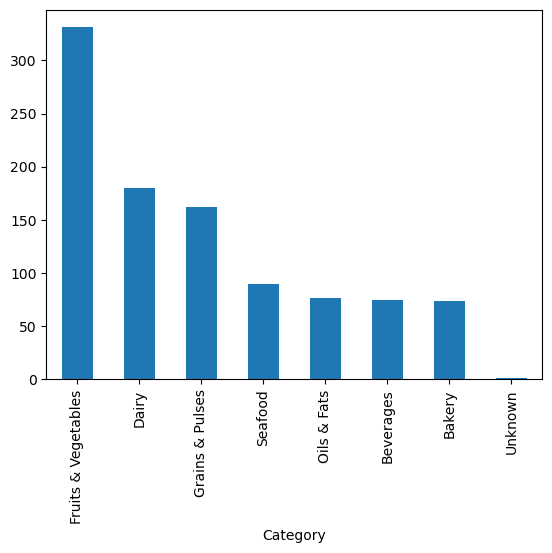

In [24]:
import matplotlib.pyplot as plt

df["Category"].value_counts().plot(kind="bar")
plt.show()

In [25]:
df.to_csv("clean_inventory_ready.csv", index=False)